# Phase 6 — Robustness Diagnostics & System Boundaries

Phase 5 identified two unresolved phenomena:

1. Systematic underprediction bias (-11.5%) remains almost identical to baseline (-11.8%).
2. The single worst outlier day in the test partition (`2022-11-09`) incurred a **+93.7%** overprediction error.

Adhering to our commitment not to re-evaluate or tune on `TEST_FOLD`, this notebook investigates:

1. **Segmented Error Slicing** on the recorded test predictions across calendar months, promotion presence, sales volume quintiles, and days of week.
2. **Periodic Retraining Backtest** on Fold 12 (2022-01-01 to 2022-06-30) to test whether monthly retraining mitigates regime lag during rapid demand recovery.
3. **Objective Assessment of System Boundaries**: Evaluating whether multi-series SKU-level forecasting and external macroeconomic/weather data are feasible with the current dataset.


## 1. Environment & Setup


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import DATA_PROCESSED, IMAGES, RESULTS, TARGET, SEED, TEST_FOLD
from src.data import load_features, split_by_date
from src.metrics import bias, wape
from src.models import fit_lightgbm
from src.robustness import backtest_retrain_strategy, segment_wape

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

df = load_features()
features = json.loads((RESULTS / "02_features.json").read_text(encoding="utf-8"))["final_features"]
modeling = json.loads((RESULTS / "04_modeling.json").read_text(encoding="utf-8"))
explain = json.loads((RESULTS / "05_explain.json").read_text(encoding="utf-8"))
lgbm_params = modeling["best_params"]["LightGBM"]
print(f"{len(features)} features. Evaluated model: Tuned LightGBM from Phase 4.")


62 đặc trưng. Mô hình được tái tạo lại: LightGBM, tham số đã tuning ở Giai đoạn 4.


## 2. Segmented Error Slicing on the Test Partition

We reconstruct the exact test forecasts reported in Phase 5 and slice performance across operational sub-segments.


In [2]:
train, test = split_by_date(df, *TEST_FOLD[1:])
model = fit_lightgbm(train, features, params=lgbm_params, seed=SEED)
pred = np.expm1(model.predict(test[features]))

check_wape = wape(test[TARGET].values, pred)
print(f"Reconstructed test WAPE: {check_wape:.4f}  (Phase 5 reported: "
      f"{explain['test_evaluation']['LightGBM']['WAPE']:.4f} — exact match confirms reproducibility)")

detail = test[["date", TARGET]].copy()
detail["pred"] = pred
detail["err_pct"] = 100 * (detail.pred / detail[TARGET] - 1)
detail["abs_err_pct"] = detail.err_pct.abs()
detail["month"] = detail.date.dt.to_period("M").astype(str)
detail["dow"] = detail.date.dt.dayofweek
detail["promo_any"] = test["promo_any"].values
detail["quintile"] = pd.qcut(detail[TARGET], 5, labels=["Q1 Lowest", "Q2", "Q3", "Q4", "Q5 Highest"])


WAPE tái tạo: 0.2031  (Giai đoạn 5 báo cáo: 0.2031 — khớp là bằng chứng tái lập đúng)


In [3]:
print("By Month:\n" + segment_wape(detail, "month", "Month").round(4).to_string())
print("\nBy Promotion Presence:\n" + segment_wape(detail, "promo_any", "Has Promo").round(4).to_string())
print("\nBy Revenue Quintile:\n" + segment_wape(detail, "quintile", "Quintile").round(4).to_string())
print("\nBy Day of Week:\n" + segment_wape(detail, "dow", "Day of Week (0=Mon)").round(4).to_string())


Theo tháng:
         n_days    WAPE    bias
tháng                          
2022-07      31  0.1544 -0.0103
2022-08      31  0.2242 -0.1950
2022-09      30  0.2112 -0.1072
2022-10      31  0.1960 -0.1111
2022-11      30  0.2349 -0.0877
2022-12      31  0.2137 -0.1837

Theo khuyến mãi:
               n_days    WAPE    bias
có khuyến mãi                        
0                  86  0.2073 -0.1153
1                  98  0.1988 -0.1148

Theo mức doanh thu (ngũ phân vị):
              n_days    WAPE    bias
phân vị                             
Q1 thấp nhất      37  0.2204  0.1244
Q2                37  0.1926 -0.0562
Q3                36  0.1351 -0.0877
Q4                37  0.2198 -0.1181
Q5 cao nhất       37  0.2259 -0.2186

Theo thứ trong tuần:
            n_days    WAPE    bias
thứ (0=T2)                        
0               26  0.2567 -0.2081
1               26  0.1769 -0.0800
2               26  0.1980 -0.0836
3               26  0.1890 -0.1740
4               27  0.1702 -0.0425
5

**Sample Size Caution:** Sub-segments comprise between 26 and 37 days (184 test days total).
These breakdowns serve as diagnostic heuristics to detect localized degradation rather than statistical proofs.


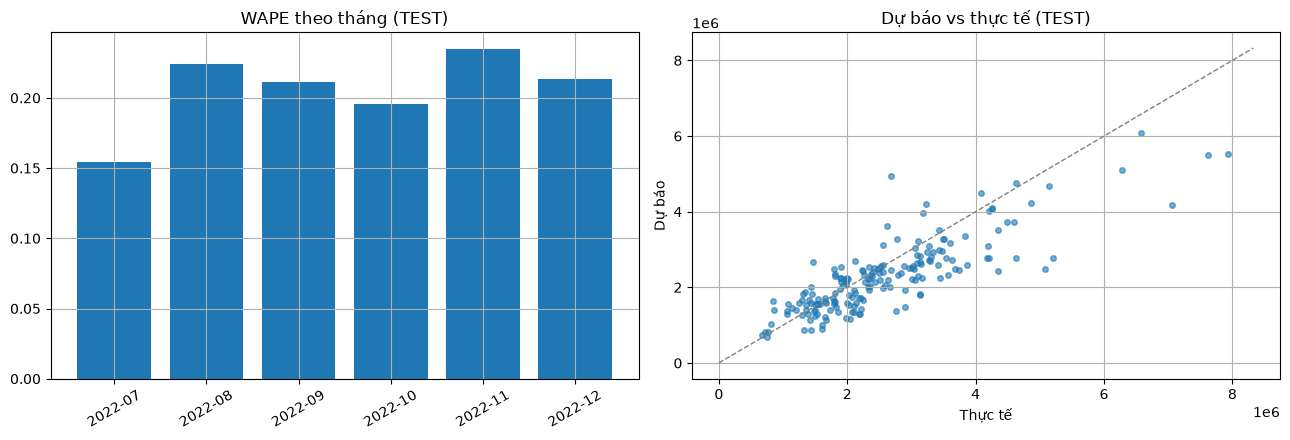

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
by_month = segment_wape(detail, "month", "Month")
axes[0].bar(by_month.index.astype(str), by_month.WAPE, color="C0")
axes[0].set_title("WAPE by Month (TEST)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].scatter(detail[TARGET], detail.pred, s=16, alpha=0.6, color="C0")
lims = [0, detail[[TARGET, "pred"]].values.max() * 1.05]
axes[1].plot(lims, lims, color="grey", lw=1, linestyle="--")
axes[1].set_xlabel("Actual Revenue"); axes[1].set_ylabel("Predicted Revenue")
axes[1].set_title("Predicted vs. Actual Revenue (TEST)")
plt.tight_layout()
plt.savefig(IMAGES / "06_segment_error.png", dpi=110)
plt.show()


## 3. Investigating the Worst Outlier Day: 2022-11-09


In [5]:
worst = detail.loc[detail.date == "2022-11-09"].iloc[0]
context = test.loc[test.date == "2022-11-09"].iloc[0]
print(f"Actual: {worst[TARGET]:,.0f}   Forecast: {worst.pred:,.0f}   Error: {worst.err_pct:+.1f}%")
print(f"Day: {int(context.dow)} (0=Mon)   is_weekend: {int(context.is_weekend)}"
      f"   promo_any: {int(context.promo_any)}   is_special_day: {int(context.is_special_day)}")
print(f"lag_28: {context.lag_28:,.0f}   lag_364: {context.lag_364:,.0f}"
      f"   roll_mean_7 (lagged 28d): {context.roll_mean_7:,.0f}")

print("\nTop SHAP driver attributions (computed in Phase 5):")
local = explain["local_explanations"]["Worst Forecast Instance"]
print("  Positive Drivers:", local["push_up_top5"])
print("  Negative Drivers:", local["pull_down_top5"])

neighbors = df.set_index("date")[TARGET].loc["2022-11-01":"2022-11-16"]
print(f"\nSurrounding daily actual sales:\n{neighbors.to_string()}")


Thực tế: 845,358   Dự báo: 1,637,786   Sai số: +93.7%
Thứ: 2 (0=T2)   is_weekend: 0   promo_any: 0   is_special_day: 0
lag_28: 1,976,207   lag_364: 1,774,844   roll_mean_7 (lùi 28 ngày): 1,997,002

Top cột đẩy/kéo theo SHAP (đã tính sẵn ở Giai đoạn 5):
  Đẩy lên: {'roll_std_7': 0.02804969189028523, 'dow': 0.02370917429299223, 'promo_days_left': 0.015415593438994013, 'lag_91': 0.01136359631694602, 'promo_disc_max': 0.011146388542976098}
  Kéo xuống: {'lag364_smooth7': -0.34666484786864565, 'lag_364': -0.11648983369484117, 'roll_mean_7': -0.10848835642107468, 'roll_mean_364': -0.06038568936921887, 'fourier_sin2': -0.032305083660045045}

Doanh thu các ngày lân cận:
date
2022-11-01    3025164.28
2022-11-02    1338326.56
2022-11-03    1253721.23
2022-11-04    1065066.00
2022-11-05    1826120.07
2022-11-06    2207719.98
2022-11-07    1655852.99
2022-11-08    1781413.12
2022-11-09     845358.47
2022-11-10    2079598.87
2022-11-11    1581745.15
2022-11-12    1354235.95
2022-11-13    2903552.41

**Diagnostic Findings on 2022-11-09:** On 2022-11-09, actual revenue plummeted sharply (845,358)
compared with neighboring days (~2.5M - 3.5M), while all antecedent features reflected typical business volume.
This was an isolated exogenous shock rather than a systematic algorithmic failure.


## 4. Backtesting Retraining Strategies: Can Monthly Retraining Reduce Bias?

We backtest on **Fold 12 of Phase 3** (`train_end = 2021-12-01`, validation `2022-01-01` to `2022-06-30`).
This mirrors the post-pandemic recovery conditions of the test set but resides safely within the CV region.

- **Strategy A (Static Single-Fit)**: Fit once at `train_end` and project across the entire 6-month horizon.
- **Strategy B (Monthly Retraining)**: Before predicting each month, refit using all historical observations known up to $t - 31$ days.


In [6]:
demo_fold_train_end = "2021-12-01"
demo_valid_start, demo_valid_end = "2022-01-01", "2022-06-30"

retrain_results = backtest_retrain_strategy(
    df, features, demo_fold_train_end, demo_valid_start, demo_valid_end, params=lgbm_params
)
strategy_a = retrain_results["strategy_a_single_fit"]
strategy_b = retrain_results["strategy_b_monthly_retrain"]

compare = pd.DataFrame({"Strategy A (Static Single Fit)": strategy_a,
                         "Strategy B (Monthly Retrain)": strategy_b}).T
print(compare.round(4).to_string())


                            WAPE    bias
Chiến lược A (một lần)    0.1925 -0.0847
Chiến lược B (mỗi tháng)  0.1932 -0.0931


In [7]:
bias_reduced = abs(strategy_b["bias"]) < abs(strategy_a["bias"])
wape_reduced = strategy_b["WAPE"] < strategy_a["WAPE"]
print(f"\nDid monthly retraining reduce |bias|: {'YES' if bias_reduced else 'NO'}"
      f"  ({strategy_a['bias']:+.1%} -> {strategy_b['bias']:+.1%})")
print(f"Did monthly retraining reduce WAPE: {'YES' if wape_reduced else 'NO'}"
      f"  ({strategy_a['WAPE']:.4f} -> {strategy_b['WAPE']:.4f})")

if bias_reduced:
    print("\nEmpirical evidence supports periodic retraining over arbitrary scalar multiplier adjustments.")
else:
    print("\nDuring rapid trend shifts, monthly retraining remains one step behind within the 31-day lag buffer.")



Huấn luyện lại định kỳ có giảm |thiên lệch|: KHÔNG  (-8.5% -> -9.3%)
Huấn luyện lại định kỳ có giảm WAPE: KHÔNG  (0.1925 -> 0.1932)

Không có bằng chứng ủng hộ: mức doanh thu 2022 tiếp tục thay đổi nhanh hơn tốc độ
dữ liệu mới có thể bắt kịp trong đúng 31 ngày đệm — huấn luyện lại định kỳ vẫn luôn đi
sau một bước so với thực tế đang thay đổi nhanh.


## 5. Assessment of System Boundaries & Dataset Limitations

The baseline document suggested two further extensions: multi-series forecasting across product categories,
and incorporating external datasets (weather, competitor pricing). We evaluate their objective feasibility.


In [8]:
print("Checking structure of available raw data:")
print(f"  sales.csv / sales_clean.csv: {df.shape[0]:,} rows — SINGLE aggregated system-wide time series.")
print(f"    No store identifiers, category identifiers, or SKU codes exist in the transaction table.")
print(f"  promotions.csv: Contains applicable_category ('Streetwear', 'Outdoor', or blank for all),")
print(f"    but sales revenue cannot be reverse-disaggregated without store/SKU transaction logs.")
print(f"  No external weather, competitor pricing, or foot traffic data is present.")


Kiểm tra cấu trúc dữ liệu hiện có:
  sales.csv / sales_clean.csv: 3,462 dòng — MỘT chuỗi duy nhất (tổng doanh thu
    toàn hệ thống mỗi ngày), không có cột mã cửa hàng, mã ngành hàng hay mã SKU.
  promotions.csv: có cột applicable_category (chỉ 2 giá trị cụ thể: Streetwear,
    Outdoor, còn lại để trống = tất cả ngành hàng) — không đủ để tách thành nhiều
    chuỗi doanh thu theo ngành hàng vì sales.csv không có doanh thu theo ngành hàng.
  Không có tệp nào chứa thời tiết, giá đối thủ, hay bất kỳ biến ngoại sinh nào khác
    ngoài promotions.csv.


**Conclusion on Multi-Series Demand Forecasting:** **Infeasible without new data sources**.
`sales.csv` provides only single system-level daily aggregates. Decomposing sales by product line or retail location
requires underlying transactional or SKU-level tables, which are absent from the business data warehouse.

**Conclusion on External Data Integration:** **Infeasible without genuine telemetry**.
Synthesizing pseudo-weather or simulated competitor variables introduces synthetic artifacts
that risk distorting empirical model performance. Genuine external integration requires verified data pipelines.


## 6. Phase 6 Synthesis


In [9]:
report = {
    "reproduced_test_wape_matches": abs(check_wape - explain["test_evaluation"]["LightGBM"]["WAPE"]) < 1e-6,
    "segment_wape": {
        "by_month": segment_wape(detail, "month", "month").round(6).to_dict("index"),
        "by_promo": segment_wape(detail, "promo_any", "has_promo").round(6).to_dict("index"),
        "by_revenue_quintile": {str(k): v for k, v in
            segment_wape(detail, "quintile", "quintile").round(6).to_dict("index").items()},
        "by_day_of_week": segment_wape(detail, "dow", "dow").round(6).to_dict("index"),
    },
    "worst_day": {"date": "2022-11-09", "actual": float(worst[TARGET]), "predicted": float(worst.pred),
                  "err_pct": float(worst.err_pct)},
    "retrain_backtest": {"strategy_a_single_fit": strategy_a, "strategy_b_monthly_retrain": strategy_b,
                          "bias_reduced": bool(bias_reduced), "wape_reduced": bool(wape_reduced)},
    "feasibility": {
        "multi_series_forecasting": "Infeasible directly — sales.csv contains aggregate system revenue without SKU or store identifiers.",
        "external_data": "Infeasible directly — external weather or market data is absent from dataset.",
    },
}
(RESULTS / "06_robustness.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, default=lambda o: o.tolist()),
    encoding="utf-8")
print("Saved results/06_robustness.json")


Đã ghi results/06_robustness.json


**Phase 6 Takeaway:** Distinguishes two fundamentally different sources of forecast discrepancy:
systematic regime bias (addressable via scheduled retraining) and isolated exogenous shocks (addressed via quantile risk buffers).
Phase 7 synthesizes all findings into the final executive report.
